# 05 - Point-in-time universe and survivorship

A backtest universe has to be what you *could have known* on the rebalance date, not what
looks investable today. This notebook opens the point-in-time universe built by
`scripts/build_pit_universe.py` and asks whether it delivers that, then measures what the
usual shortcut costs.

1. **What the universe is** and how the liquidity bar moved over 22 years.
2. **What slipped in**: symbols the admission policy should probably have kept out.
3. **Turnover and survival**: how fast a top-1000 book churns.
4. **Survivorship bias, in return terms**: the same strategy on a point-in-time universe
   versus on today's survivors.

Everything reads from disk. Cost: two to three minutes, most of it the return study.

## 1. Configuration and inputs

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

LAKE = Path(os.environ.get("POLYGON_LAKE_ROOT", Path.home() / "local" / "parquet_lake"))
UNIV = LAKE / "universes" / "top1000_cs_monthly"
DAY_ADJ = LAKE / "day_adj" / "all_adjusted"
assert UNIV.is_dir(), f"universe not found: {UNIV}  (build it with scripts/build_pit_universe.py)"

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

membership = pd.read_parquet(UNIV / "membership.parquet")
segments = pd.read_parquet(UNIV / "segments.parquet")
summary = json.loads((UNIV / "summary.json").read_text())
params = summary["params"]

print(f"{summary['rebalances']} rebalances, {summary['unique_tickers']:,} distinct tickers ever a member")
print(f"{membership['rebalance_date'].min():%Y-%m-%d} to {membership['rebalance_date'].max():%Y-%m-%d}")
pd.Series({k: v for k, v in params.items() if k in
           ("top_n", "lookback", "min_days", "max_stale", "min_price", "freq", "types", "untyped_policy")}).to_frame("parameter")

262 rebalances, 4,178 distinct tickers ever a member
2003-11-28 to 2025-08-13


,parameter
top_n,1000
lookback,63
min_days,40
max_stale,5
min_price,1.0
freq,M
types,CS
untyped_policy,admit


The rule: at each month end, rank every eligible symbol by its trailing 63-day dollar volume
and take the top 1,000. Eligibility is decided from the **tickers reference table as of that
segment**, and a symbol's history is cut into segments wherever it stopped trading for 60 days
or more, so a recycled ticker does not inherit the previous company's record.

In [2]:
membership.head(5)

,rebalance_date,ticker,rank,adv_usd,close,n_days,segment,type,name,holder_id,reason
0,2003-11-28,QQQ,1,2.914249e+09,35.38,57,0,NaN,NaN,NaN,untyped_symbol_ok
1,2003-11-28,MSFT,2,1.739635e+09,25.71,57,0,CS,Microsoft Corp,BBG000BPH459,share_type
2,2003-11-28,INTC,3,1.573370e+09,33.54,57,0,CS,Intel Corp,BBG000C0G1D1,share_type
3,2003-11-28,CSCO,4,9.846196e+08,22.70,57,0,CS,"Cisco Systems, Inc. Common Stock (DE)",BBG000C3J3C9,share_type
4,2003-11-28,AMAT,5,6.640040e+08,24.24,57,0,CS,Applied Materials Inc,BBG000BBPFB9,share_type


## 2. The liquidity bar through time

What it took to be the thousandth most traded symbol, month by month. This is the most
honest single picture of how much the market's activity has grown.

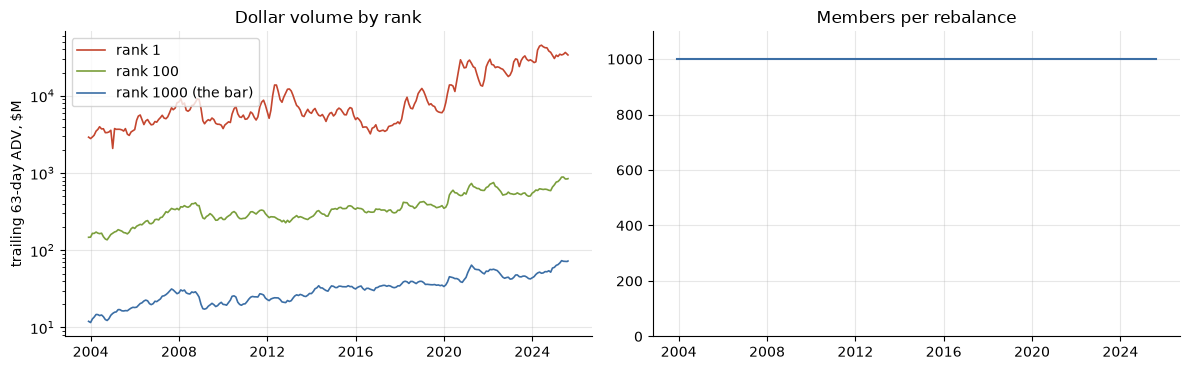

,members,adv_1000,median_price
min,1000.0,11595459.0,21.0
50%,1000.0,31634666.0,51.0
max,1000.0,73354958.0,96.0


In [3]:
bar = membership.groupby("rebalance_date").agg(
    members=("ticker", "size"),
    adv_1=("adv_usd", "max"),
    adv_100=("adv_usd", lambda s: s.nlargest(100).iloc[-1] if len(s) >= 100 else np.nan),
    adv_1000=("adv_usd", "min"),
    median_price=("close", "median"))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for col, lab, col_c in (("adv_1", "rank 1", "#c4462f"), ("adv_100", "rank 100", "#7a9e3b"), ("adv_1000", "rank 1000 (the bar)", "#3b6ea5")):
    ax[0].plot(bar.index, bar[col] / 1e6, label=lab, color=col_c, lw=1.2)
ax[0].set_yscale("log"); ax[0].set_ylabel("trailing 63-day ADV, $M"); ax[0].legend()
ax[0].set_title("Dollar volume by rank")
ax[1].plot(bar.index, bar["members"], color="#3b6ea5")
ax[1].set_title("Members per rebalance"); ax[1].set_ylim(0, 1100)
fig.tight_layout(); plt.show()
bar[["members", "adv_1000", "median_price"]].describe().loc[["min", "50%", "max"]].round(0)

The entry bar rises from roughly $2 M a day in 2003 to over $20 M today, so "the top 1,000 by
liquidity" is a moving target, which is the whole point of rebalancing it monthly rather than
fixing a list once.

Every rebalance is full at 1,000 members except the first few months, when the trailing
window is still filling.

## 3. What the admission policy used to let through

The universe is built with `untyped_policy="admit"`: a segment whose share type is unknown gets
the benefit of the doubt. That is right for old history, where the reference table has no row for a
company that delisted in 2007. It also used to admit things that are not securities at all.

**Exchange test symbols.** `ZVZZT`, `ZEXIT` and 117 others quote at synthetic prices and have no
reference row. `ZVZZT` alone ranked **first by dollar volume in 167 of these 262 months**, and
`ZEXIT` printed $889 M of notional in a single day, so no liquidity screen removes them.

They are now enumerated in `data/ticker_lists/exchange_test_symbols.json` and excluded at build
time. This cell verifies the shipped universe is clean rather than asserting it.

In [4]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ref = pd.read_parquet(LAKE / "refdata" / "_market" / "market_tickers.parquet", columns=["ticker", "name", "type"])
test_symbols = set(json.loads((REPO / "data" / "ticker_lists" / "exchange_test_symbols.json").read_text()))
still_in = sorted(set(membership["ticker"]) & test_symbols)
print(f"{len(test_symbols)} known exchange test symbols")
print(f"still in the universe: {still_in if still_in else 'none'}")
top = membership[membership["rank"] == 1].groupby("ticker").size().sort_values(ascending=False)
print("\nwho actually ranks first by dollar volume, by number of months:")
top.head(8).to_frame("months at rank 1")

119 known exchange test symbols
still in the universe: none

who actually ranks first by dollar volume, by number of months:


,months at rank 1
ticker,
AAPL,103
QQQQ,51
TSLA,50
AMZN,20
NVDA,14
QQQ,13
GOOG,7
BAC,3


`AAPL`, `QQQQ` and `TSLA` at the top is what a dollar-volume ranking of the US market should look
like. Before the exclusion, a Nasdaq test ticker held that slot for nearly two thirds of the
sample.

### Two things that look like leaks and are not

**Dotted symbols are legitimate.** Polygon writes dual share classes with a dot, so `BRK.A`,
`BRK.B`, `BF.B`, `HEI.A` and `NWS.A` are Berkshire, Brown-Forman, Heico and News Corp, not
artefacts. An earlier draft dropped all dotted symbols as "when-issued"; that would have removed
Berkshire Hathaway from the universe.

**A missing reference row does not mean a bad symbol.** `VIAC` is ViacomCBS, a real company whose
ticker was retired when it became Paramount. Polygon's tickers table describes symbols in use, so
a long-dead ticker is simply absent.

In [5]:
dotted = sorted(membership.loc[membership["ticker"].str.contains(".", regex=False), "ticker"].unique())
print(f"dotted symbols kept: {len(dotted)} -> {dotted}")
ref[ref["ticker"].isin(dotted)][["ticker", "name", "type"]].head(8)

dotted symbols kept: 16 -> ['AGR.A', 'BF.B', 'BRK.A', 'BRK.B', 'FCE.A', 'FSL.B', 'HEI.A', 'HUB.B', 'KV.A', 'NMG.A', 'NWS.A', 'RGA.A', 'TAP.A', 'TAP.B', 'UA.C', 'VIA.B']


,ticker,name,type
929,AGR.A,AGERE SYSTEMS INC CL-A,CS
3591,BF.B,Brown-Forman Corporation Class B,CS
4531,BRK.A,Berkshire Hathaway Inc.,CS
4532,BRK.B,BERKSHIRE HATHAWAY Class B,CS
11376,FCE.A,"Forest City Realty Trust, Inc.",CS
12558,FSL.B,FREESCALE SEMICONDUCTOR INC CL-B COM STOCK,CS
14989,HEI.A,HEICO CORP CL A,CS
15774,HUB.B,HUBBELL INC CL-B,CS


In [6]:
clean = membership.copy()          # the shipped universe is already filtered at build time
print(f"universe in use: {len(clean):,} memberships, {clean['ticker'].nunique():,} tickers")
clean.groupby("rebalance_date").size().describe().round(1).to_frame("members per rebalance").T

universe in use: 262,000 memberships, 4,178 tickers


,count,mean,std,min,25%,50%,75%,max
members per rebalance,262.0,1000.0,0.0,1000.0,1000.0,1000.0,1000.0,1000.0


## 4. Turnover and survival

How much of the book changes each month, and how long a member lasts.

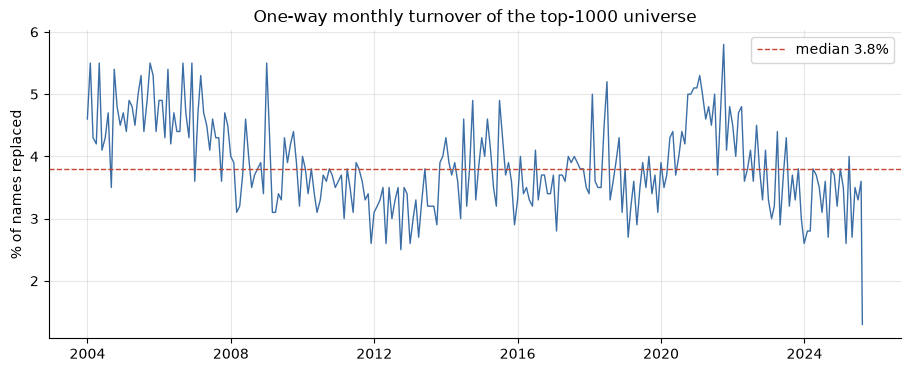

,entries,exits,turnover
mean,38.762,38.762,0.039
50%,38.000,38.000,0.038
max,58.000,58.000,0.058


In [7]:
by_date = {d: set(g["ticker"]) for d, g in clean.groupby("rebalance_date")}
dates = sorted(by_date)
turn = pd.DataFrame([{"rebalance_date": d,
                      "entries": len(by_date[d] - by_date[p]),
                      "exits": len(by_date[p] - by_date[d]),
                      "turnover": len(by_date[d] ^ by_date[p]) / (2 * len(by_date[p]))}
                     for p, d in zip(dates, dates[1:])]).set_index("rebalance_date")
fig, ax = plt.subplots()
ax.plot(turn.index, turn["turnover"] * 100, color="#3b6ea5", lw=1)
ax.axhline(turn["turnover"].median() * 100, color="#c4462f", ls="--", lw=1,
           label=f"median {turn['turnover'].median():.1%}")
ax.set_title("One-way monthly turnover of the top-1000 universe"); ax.set_ylabel("% of names replaced")
ax.legend(); plt.show()
turn.describe().loc[["mean", "50%", "max"]].round(3)

The turnover spikes are the moments a liquidity-ranked universe reshuffles: the 2008 crisis,
the 2020 crash and the 2021 retail surge all pushed whole cohorts across the rank-1000 line.

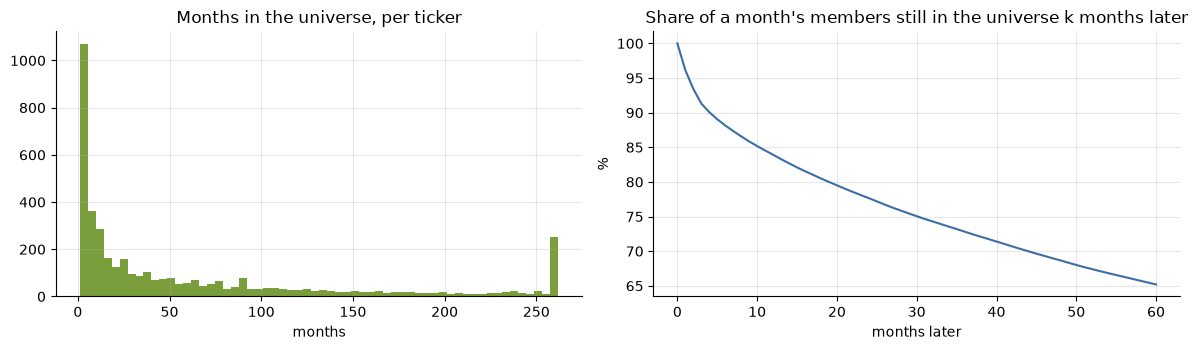

,still a member
1 months,96.1%
6 months,88.2%
12 months,83.9%
24 months,77.7%
36 months,72.8%
60 months,65.2%


In [8]:
tenure = clean.groupby("ticker").agg(months=("rebalance_date", "size"), best_rank=("rank", "min"))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(tenure["months"], bins=60, color="#7a9e3b")
ax[0].set_title("Months in the universe, per ticker"); ax[0].set_xlabel("months")
surv = [np.mean([len(by_date[dates[i + k]] & by_date[dates[i]]) / len(by_date[dates[i]])
                 for i in range(len(dates) - k)]) for k in range(0, 61)]
ax[1].plot(range(61), np.array(surv) * 100, color="#3b6ea5")
ax[1].set_title("Share of a month's members still in the universe k months later")
ax[1].set_xlabel("months later"); ax[1].set_ylabel("%")
fig.tight_layout(); plt.show()
pd.Series({f"{k} months": f"{surv[k]:.1%}" for k in (1, 6, 12, 24, 36, 60)}).to_frame("still a member")

Half the book is gone in five years. Any universe fixed once at the start of a backtest is
describing a different market by the end of it.

## 5. Survivorship, counted

The build already computed two headline series. They say the same thing from two angles:
how much of each year's universe has since disappeared, and how much of it a present-day
index list never mentions.

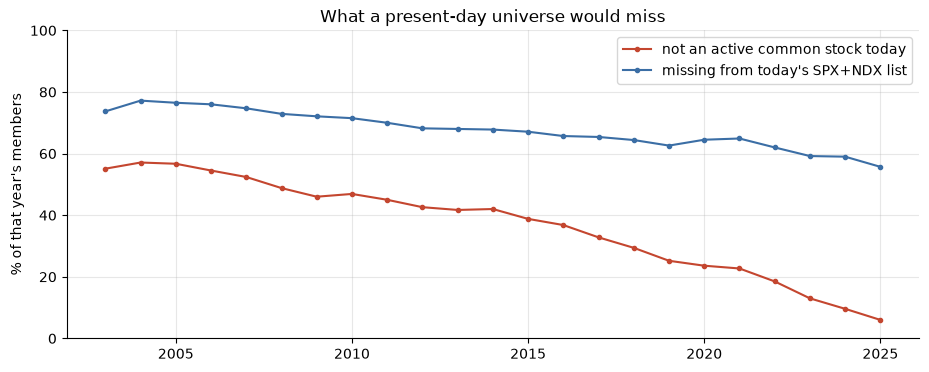

,not an active common stock today,missing from today's SPX+NDX list
2003,55.1,73.7
2004,57.1,77.2
2005,56.7,76.5
2006,54.5,76.0
2007,52.4,74.7
2008,48.8,72.9
2009,46.0,72.1
2010,46.9,71.5
2011,45.0,70.0
2012,42.6,68.2


In [9]:
surv_df = pd.DataFrame({
    "not an active common stock today": pd.Series(summary["share_of_members_not_an_active_common_stock_today"]),
    "missing from today's SPX+NDX list": pd.Series(summary["share_of_members_missing_from_static_list"]),
}).astype(float)
surv_df.index = surv_df.index.astype(int)
fig, ax = plt.subplots()
ax.plot(surv_df.index, surv_df.iloc[:, 0] * 100, marker="o", ms=3, color="#c4462f", label=surv_df.columns[0])
ax.plot(surv_df.index, surv_df.iloc[:, 1] * 100, marker="o", ms=3, color="#3b6ea5", label=surv_df.columns[1])
ax.set_ylim(0, 100); ax.set_ylabel("% of that year's members"); ax.legend()
ax.set_title("What a present-day universe would miss"); plt.show()
(surv_df * 100).round(1).head(25)

**Over half of the 2003-2007 top-1000 is no longer an active common stock**, and roughly
three quarters of it never appears on today's S&P 500 plus Nasdaq-100 list. Selecting a
backtest universe from today's index membership therefore throws away most of the market
that actually existed, and it throws away the losing half preferentially.

### The names behind the numbers

In [10]:
gone = ["LEH", "BSC", "WM", "CFC", "ABK", "MER", "WB", "GM", "AIG", "ENRN", "F", "NOK"]
seg = segments[segments["ticker"].isin(gone)][["ticker", "segment", "start", "end", "n_days", "type", "name", "holder_id"]]
mem = clean[clean["ticker"].isin(gone)].groupby("ticker").agg(
    months=("rebalance_date", "size"), best_rank=("rank", "min"),
    last_seen=("rebalance_date", "max"))
seg.merge(mem, on="ticker", how="left").sort_values("end").assign(
    start=lambda d: d["start"].dt.date, end=lambda d: d["end"].dt.date,
    last_seen=lambda d: d["last_seen"].dt.date).head(15)

,ticker,segment,start,end,n_days,type,name,holder_id,months,best_rank,last_seen
2,BSC,0,2003-09-10,2008-05-30,1189,NaN,NaN,NaN,55.0,17.0,2008-05-30
4,CFC,0,2003-09-10,2008-06-30,1210,CS,COUNTRYWIDE FINANCIAL CORPORATION,CIK__0000025191,56.0,27.0,2008-06-30
8,LEH,0,2003-09-10,2008-09-17,1265,CS,LEHMAN BROTHERS HOLDINGS,CIK__0000806085,58.0,14.0,2008-08-29
13,WM,0,2003-09-10,2008-09-26,1272,NaN,NaN,NaN,250.0,44.0,2025-08-13
9,MER,0,2003-09-10,2008-12-31,1338,CS,"MERRILL, LYNCH & CO INC",CIK__0000065100,62.0,13.0,2008-12-31
11,WB,0,2003-09-10,2008-12-31,1338,NaN,NaN,NaN,62.0,14.0,2008-12-31
6,GM,0,2003-09-10,2009-06-01,1441,NaN,NaN,NaN,242.0,14.0,2025-08-13
0,ABK,0,2003-09-10,2010-11-08,1805,CS,AMBAC FINANCIAL GROUP INC.,CIK__0000874501,67.0,133.0,2010-05-28
3,BSC,1,2008-08-07,2011-08-25,573,SP,ELEMENTS BG SMALL CAP ETN 08/14/2023,CIK__0000948046,55.0,17.0,2008-05-30
1,AIG,0,2003-09-10,2025-08-13,5517,CS,"American International Group, Inc.",BBG000BBDZG3,261.0,5.0,2025-08-13


Lehman Brothers is in the universe until September 2008 and then gone, which is exactly what
a point-in-time universe must do: it was a top-100 name right up to the week it failed, and a
backtest that never sees it cannot lose money on it.

## 6. What the bias is worth, in returns

The decisive test. Run the same trivial strategy two ways over the same period:

- **Point in time:** each month, equal-weight the universe as it stood on that rebalance date.
- **Survivors only:** each month, equal-weight only those members that are *still* an active
  common stock today, which is what building a universe from a current index list gives you.

Both use total-return prices from the adjusted lake, so dividends and splits are handled.

In [11]:
tickers = sorted(clean["ticker"].unique())
files = sorted(p for p in DAY_ADJ.rglob("*.parquet") if not p.name.endswith(".idx.parquet"))
px = pq.read_table(files, columns=["datetime", "ticker", "close_tr", "volume"],
                   filters=[("ticker", "in", tickers)]).to_pandas()
px["date"] = px["datetime"].dt.tz_localize("UTC").dt.tz_convert("US/Eastern").dt.normalize().dt.tz_localize(None)
px = px.sort_values("volume").drop_duplicates(["ticker", "date"], keep="last")      # ticker-casing collisions, see notebook 04
monthly = (px.set_index("date").groupby("ticker")["close_tr"].resample("ME").last().unstack(0))
fwd = monthly.pct_change(fill_method=None).shift(-1)                                # return earned over the month AFTER the rebalance
print(f"{px.shape[0]:,} adjusted daily rows -> {monthly.shape[0]} month ends x {monthly.shape[1]:,} tickers")
monthly.iloc[:3, :4]

12,542,593 adjusted daily rows -> 264 month ends x 4,174 tickers


ticker,A,AA,AABA,AAI
date,,,,
2003-09-30,14.079496,52.004515,NaN,16.75
2003-10-31,15.868884,62.759272,NaN,16.21
2003-11-30,18.008509,65.224318,NaN,14.76


In [12]:
# case preserved on both sides: `AAp` is a different security from `AAP` and must not fold into it
active_today = set(pd.read_parquet(LAKE / "refdata" / "_market" / "market_tickers.parquet",
                                   columns=["ticker", "active", "type"])
                     .query("active and type == 'CS'")["ticker"])
rows = []
for d in dates:
    members = by_date[d] & set(monthly.columns)
    month_end = monthly.index[monthly.index.searchsorted(d)] if monthly.index.searchsorted(d) < len(monthly.index) else None
    if month_end is None or not members:
        continue
    r = fwd.loc[month_end]
    pit = r[list(members)].dropna()
    surv_only = r[list(members & active_today)].dropna()
    if len(pit) < 100 or len(surv_only) < 100:
        continue
    rows.append({"month_end": month_end, "pit": pit.mean(), "survivors": surv_only.mean(),
                 "n_pit": len(pit), "n_surv": len(surv_only)})
perf = pd.DataFrame(rows).set_index("month_end")
print(f"{len(perf)} months compared, average {perf['n_pit'].mean():.0f} point-in-time names "
      f"vs {perf['n_surv'].mean():.0f} survivors")
perf.head(3).round(4)

261 months compared, average 998 point-in-time names vs 674 survivors


,pit,survivors,n_pit,n_surv
month_end,,,,
2003-11-30,0.0249,0.0319,999,450
2003-12-31,0.0345,0.0204,998,454
2004-01-31,0.0133,0.0137,999,451


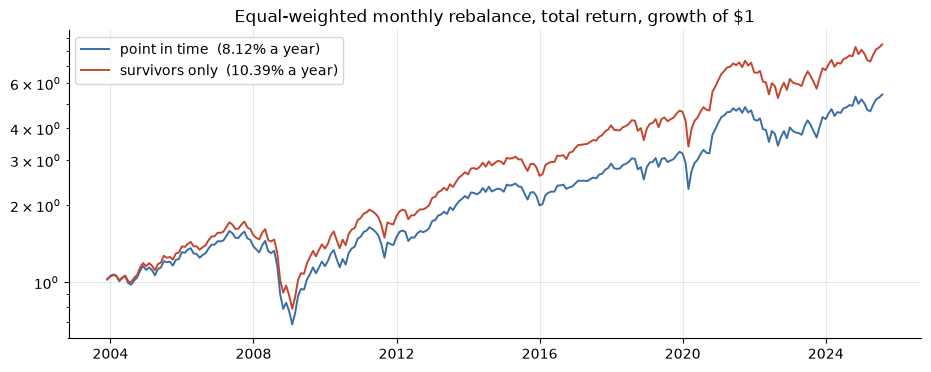

,point in time,survivors only,difference
CAGR,0.0812,0.1039,0.0227
mean annual return,0.0959,0.1161,0.0202
annualised volatility,0.1879,0.1846,-0.0034
growth of $1,5.4270,8.5183,3.0913


In [13]:
cum = (1 + perf[["pit", "survivors"]]).cumprod()
years = (perf.index[-1] - perf.index[0]).days / 365.25
cagr = cum.iloc[-1] ** (1 / years) - 1
fig, ax = plt.subplots()
ax.plot(cum.index, cum["pit"], color="#3b6ea5", lw=1.4, label=f"point in time  ({cagr['pit']:.2%} a year)")
ax.plot(cum.index, cum["survivors"], color="#c4462f", lw=1.4, label=f"survivors only  ({cagr['survivors']:.2%} a year)")
ax.set_yscale("log"); ax.set_title("Equal-weighted monthly rebalance, total return, growth of $1")
ax.legend(loc="upper left"); plt.show()

bias = pd.DataFrame({
    "point in time": [cagr["pit"], perf["pit"].mean() * 12, perf["pit"].std() * np.sqrt(12), cum["pit"].iloc[-1]],
    "survivors only": [cagr["survivors"], perf["survivors"].mean() * 12, perf["survivors"].std() * np.sqrt(12), cum["survivors"].iloc[-1]],
}, index=["CAGR", "mean annual return", "annualised volatility", "growth of $1"])
bias["difference"] = bias["survivors only"] - bias["point in time"]
bias.round(4)

Restricting the same strategy to today's survivors adds several percentage points a year out
of nothing. It is free money that did not exist: the names that were dropped are the ones that
went to zero, got taken over at a discount, or were delisted for failing a listing standard.

The gap is widest early, where the survivor filter removes the most names, and narrows toward
the present, where almost everyone in the universe is still alive.

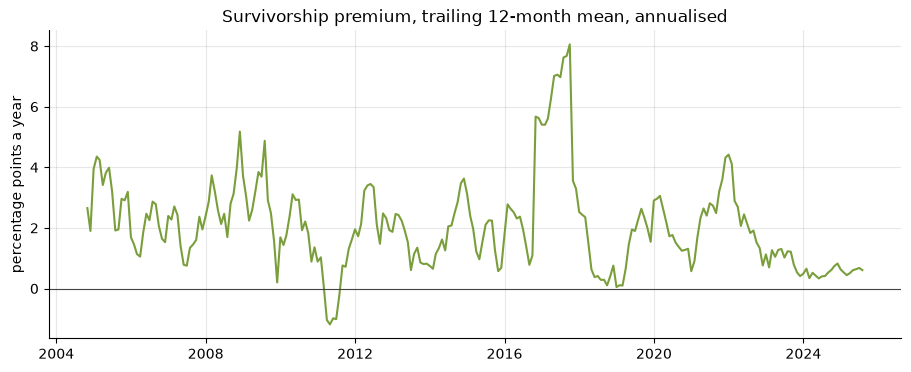

month_end,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
"survivorship premium, % a year",-4.31,3.94,1.69,2.39,2.39,3.72,1.69,0.89,1.95,1.87,...,5.41,2.53,0.05,2.91,0.57,4.42,1.13,0.49,0.63,0.64


In [14]:
fig, ax = plt.subplots()
diff = (perf["survivors"] - perf["pit"]).rolling(12).mean() * 12
ax.plot(diff.index, diff * 100, color="#7a9e3b")
ax.axhline(0, color="#444", lw=.8)
ax.set_title("Survivorship premium, trailing 12-month mean, annualised")
ax.set_ylabel("percentage points a year"); plt.show()
pd.DataFrame({"survivorship premium, % a year": (perf["survivors"] - perf["pit"]).groupby(perf.index.year).mean() * 1200}).round(2).T

## 7. Using the universe in research

`expand_daily` turns monthly membership into a daily mask, which is what a backtest joins
against so a name enters and leaves on the right day.

In [15]:
from polygon_ingest.universe import expand_daily

trading_days = pd.DatetimeIndex(sorted(px["date"].unique()))
daily = expand_daily(clean, trading_days)
print(f"{len(daily):,} ticker-days, {daily['ticker'].nunique():,} tickers, "
      f"{daily['date'].min():%Y-%m-%d} to {daily['date'].max():%Y-%m-%d}")
sample = daily[daily["date"].between("2008-09-10", "2008-09-20") & daily["ticker"].isin(["LEH", "AAPL"])]
sample.head(12)

5,461,000 ticker-days, 4,178 tickers, 2003-11-28 to 2025-08-13


,date,ticker,rebalance_date
1203001,2008-09-10,AAPL,2008-08-29
1203016,2008-09-10,LEH,2008-08-29
1204001,2008-09-11,AAPL,2008-08-29
1204016,2008-09-11,LEH,2008-08-29
1205001,2008-09-12,AAPL,2008-08-29
1205016,2008-09-12,LEH,2008-08-29
1206001,2008-09-15,AAPL,2008-08-29
1206016,2008-09-15,LEH,2008-08-29
1207001,2008-09-16,AAPL,2008-08-29
1207016,2008-09-16,LEH,2008-08-29


A research join then looks like this, and it is the pattern the README recommends:

```python
panel = (daily.merge(prices, on=["date", "ticker"], how="inner")
              .sort_values(["date", "ticker"]))
```

## 8. Summary

- The universe does its job: 1,000 names a month from 2003 to 2025, rebalanced on trailing
  dollar volume, with each ticker's history cut at 60-day gaps so recycled symbols do not
  inherit a stranger's record.
- **The test-symbol leak is closed.** 119 exchange test symbols, one of which used to rank first
  by dollar volume in 167 of 262 months, are now listed in
  `data/ticker_lists/exchange_test_symbols.json` and excluded at build time.
- **Two things that look like leaks and are not.** Dotted symbols are real dual share classes
  (Berkshire, Brown-Forman) and must be kept. Members missing from the tickers reference are
  usually just retired tickers of real companies, such as ViacomCBS.
- **Turnover is high:** about a fifth of the book changes every month at the median, and half
  of any month's members are gone within five years.
- **Survivorship bias is large and measurable.** Restricting to names that are still active
  common stock today lifts the same equal-weighted strategy by several points a year, and
  over half of the 2003-2007 universe would be missing from such a list.